# Imports

In [11]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import umap

from sklearn.cluster import KMeans
from transformers import AutoProcessor, SiglipVisionModel
from ultralytics import YOLO

base_path = os.path.join("..", "..")

# Configuracoes
VIDEO_PATH = os.path.join(base_path, "videos/basquete.mp4") # Coloque o caminho do seu video aqui
DETECTOR_WEIGHTS = os.path.join(base_path, "models/detector/yolo26m-basketball.pt")
SEG_WEIGHTS = os.path.join(base_path, "models/seg/yolo26m-seg.pt")
PLAYER_CLASS_IDS = {3, 4, 5, 6, 7} # Seus IDs de jogadores detectados anteriormente

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[*] Usando dispositivo: {device}")

# Carregando Modelos
print("[*] Carregando YOLO Detector...")
detector = YOLO(DETECTOR_WEIGHTS)

print("[*] Carregando YOLO Segmenter...")
segmenter = YOLO(SEG_WEIGHTS)

print("[*] Carregando SigLIP Vision Backbone...")
processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")
siglip_model = SiglipVisionModel.from_pretrained("google/siglip-base-patch16-224").to(device)
siglip_model.eval()

print("[*] Setup concluido.")

[*] Usando dispositivo: cuda
[*] Carregando YOLO Detector...
[*] Carregando YOLO Segmenter...
[*] Carregando SigLIP Vision Backbone...


Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 7710.12it/s]


[*] Setup concluido.


# Data Mining

In [12]:
# %% [Cell 2 - VERSÃO SEM SEGMENTAÇÃO]
print("[*] Minerando crops brutos (apenas Bounding Box) do video...")
cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

golden_crops = [] # Mantido com o mesmo nome para as células seguintes funcionarem nativamente
target_crops = 100

for progress in np.arange(0.1, 0.9, 0.05): # Amostra ao longo do video
    if len(golden_crops) >= target_crops:
        break
        
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(total_frames * progress))
    ret, frame = cap.read()
    if not ret: continue
        
    # Rodamos apenas o detector, ignorando o segmentador completamente
    det_results = detector.predict(frame, conf=0.7, verbose=False)[0]
    
    if det_results.boxes is None: continue
        
    det_boxes = det_results.boxes.xyxy.cpu().numpy()
    det_classes = det_results.boxes.cls.cpu().numpy()
    
    for box, cls_id in zip(det_boxes, det_classes):
        if int(cls_id) not in PLAYER_CLASS_IDS: continue
            
        x1, y1, x2, y2 = map(int, box)
        w, h = x2 - x1, y2 - y1
        
        # Mantemos apenas o filtro de tamanho básico
        if w < 20 or h < 50: continue 
            
        # Extrai o crop quadrado/retangular exatamente como o YOLO viu
        # Sem aplicar a máscara de fundo preto
        crop = frame[y1:y2, x1:x2].copy()
        golden_crops.append(crop)

cap.release()
print(f"[*] Coletados {len(golden_crops)} crops brutos (sem máscara).")

[*] Minerando crops brutos (apenas Bounding Box) do video...
[*] Coletados 77 crops brutos (sem máscara).


# Reality Check

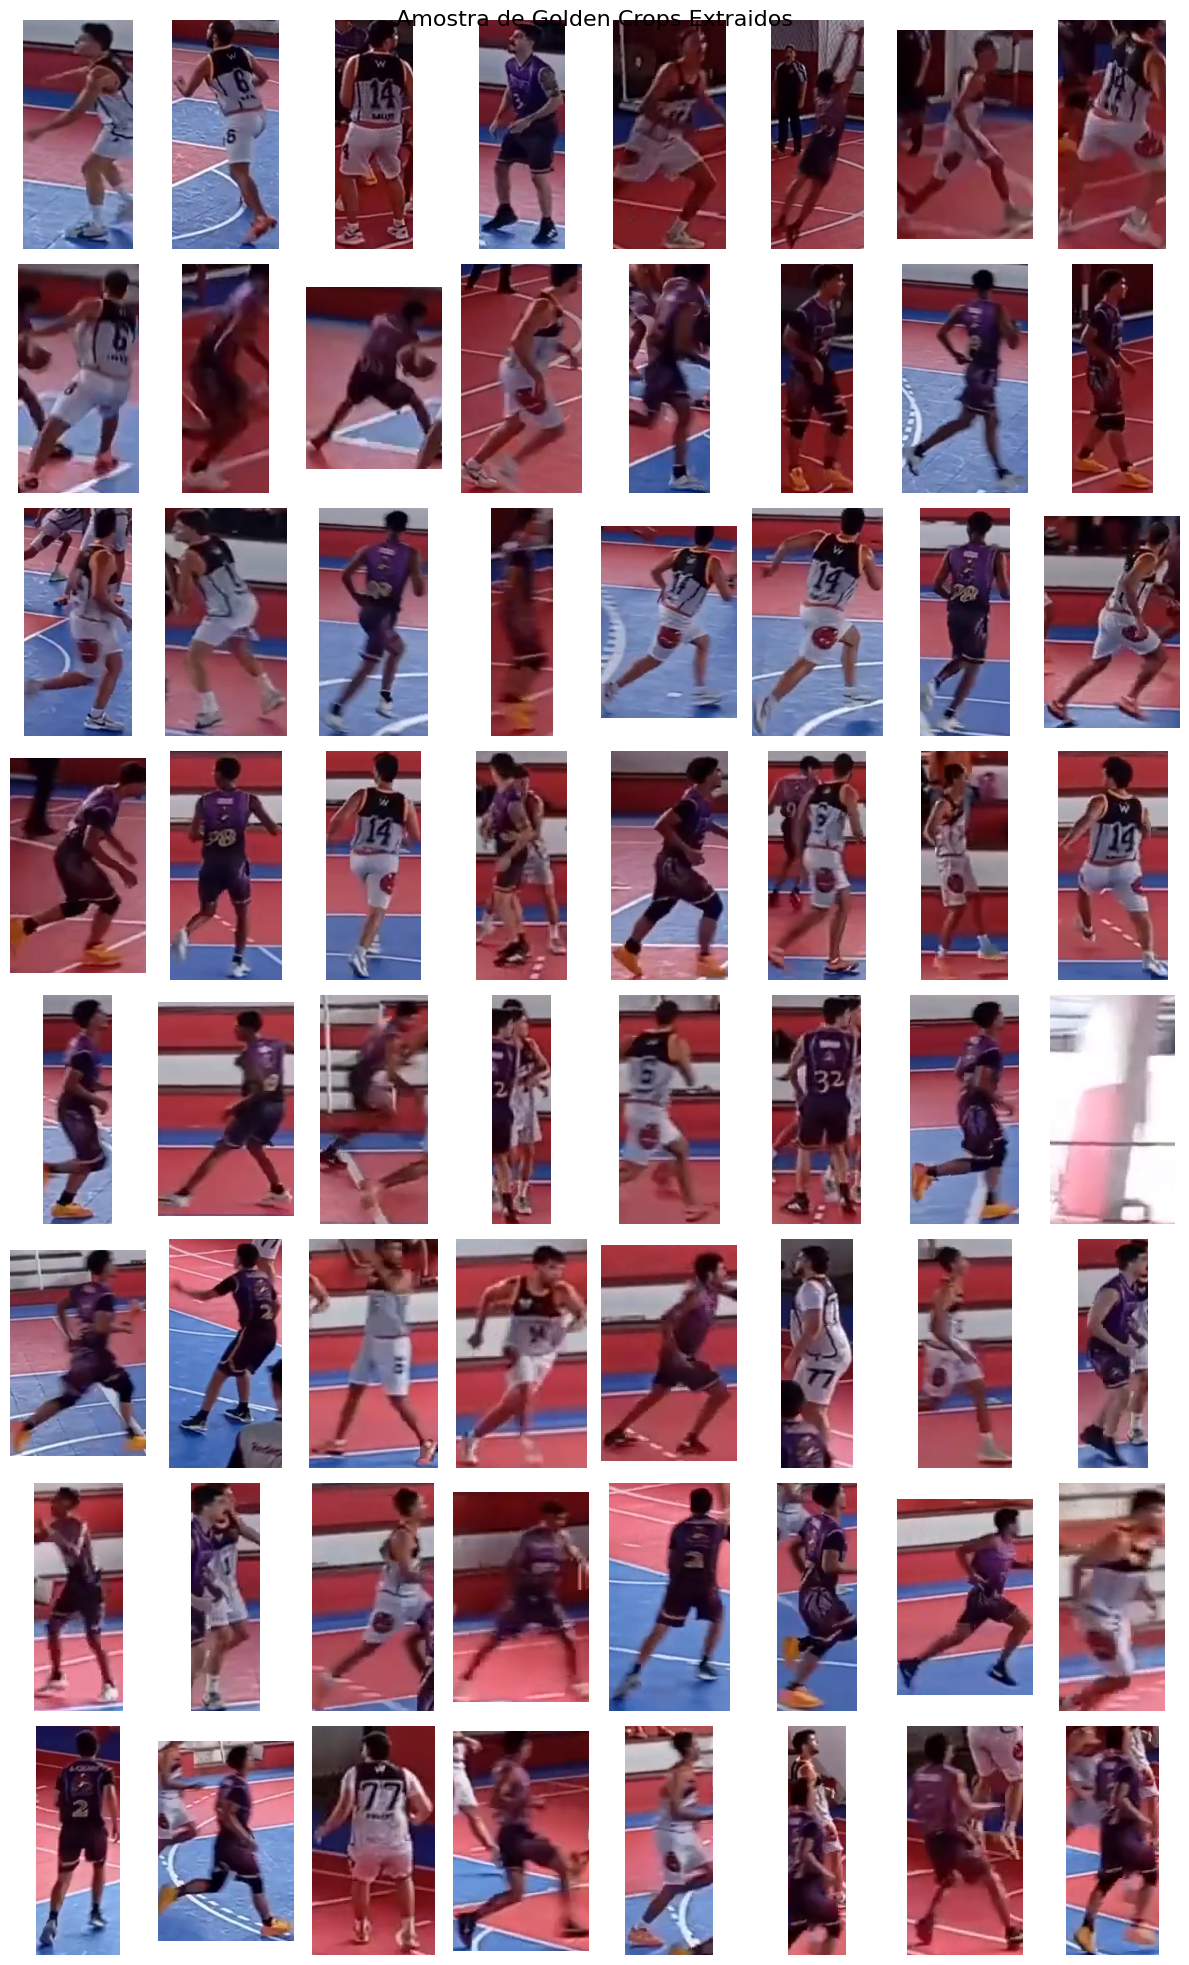

In [13]:
# %% [Cell 3]
def plot_crop_grid(crops, title, num_items=64):
    n = min(len(crops), num_items)
    cols = 8
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*2.5))
    fig.suptitle(title, fontsize=16)
    
    for i, ax in enumerate(axes.flatten()):
        if i < n:
            rgb_crop = cv2.cvtColor(crops[i], cv2.COLOR_BGR2RGB)
            ax.imshow(rgb_crop)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Observe essa imagem com atencao: Os jogadores estao bem isolados?
plot_crop_grid(golden_crops, "Amostra de Golden Crops Extraidos")

# SigLip Debug

[*] Extraindo embeddings SigLIP...
[*] Reduzindo dimensao com UMAP e clusterizando...


/home/victor/miniconda3/envs/tail/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


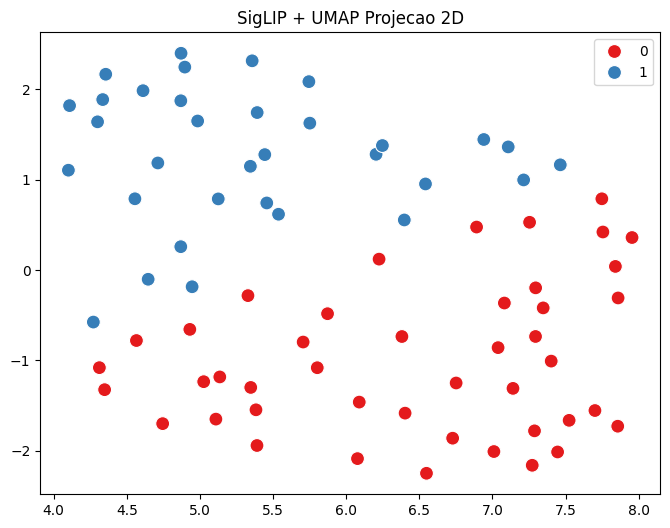

In [14]:
# %% [Cell 4]
print("[*] Extraindo embeddings SigLIP...")
siglip_embeddings = []

with torch.inference_mode():
    for crop in golden_crops:
        rgb_crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        inputs = processor(images=rgb_crop, return_tensors="pt").to(device)
        outputs = siglip_model(**inputs)
        
        # O segredo: media dos patches visuais
        features = torch.mean(outputs.last_hidden_state, dim=1)
        features = torch.nn.functional.normalize(features, dim=-1)
        siglip_embeddings.append(features.cpu().numpy()[0])

siglip_embeddings = np.array(siglip_embeddings)

print("[*] Reduzindo dimensao com UMAP e clusterizando...")
reducer_siglip = umap.UMAP(n_components=2, metric='cosine', random_state=42)
proj_siglip = reducer_siglip.fit_transform(siglip_embeddings)

kmeans_siglip = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_siglip = kmeans_siglip.fit_predict(proj_siglip)

# Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=proj_siglip[:, 0], y=proj_siglip[:, 1], hue=labels_siglip, palette="Set1", s=100)
plt.title("SigLIP + UMAP Projecao 2D")
plt.show()

# SigLip Accountability Check

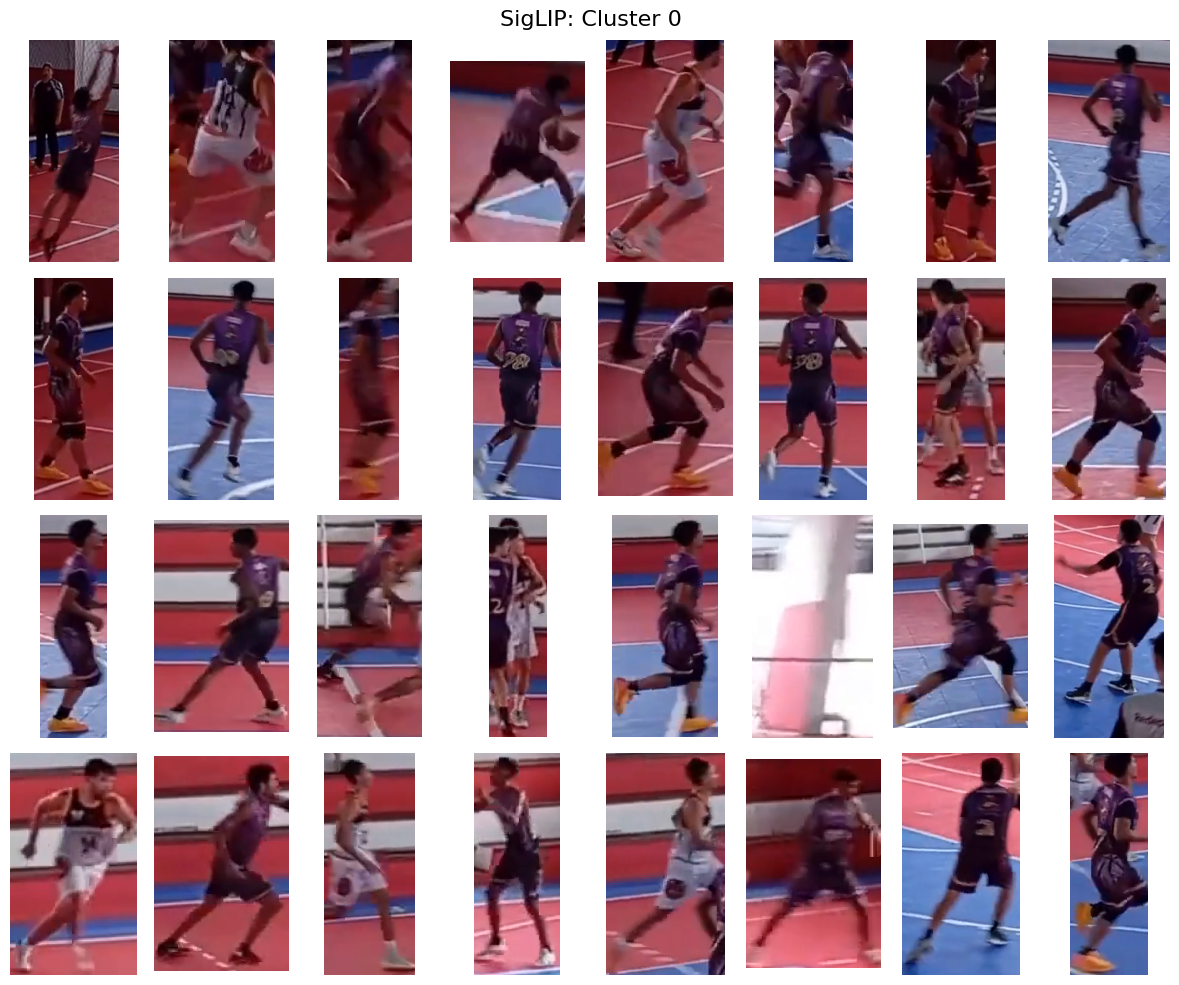

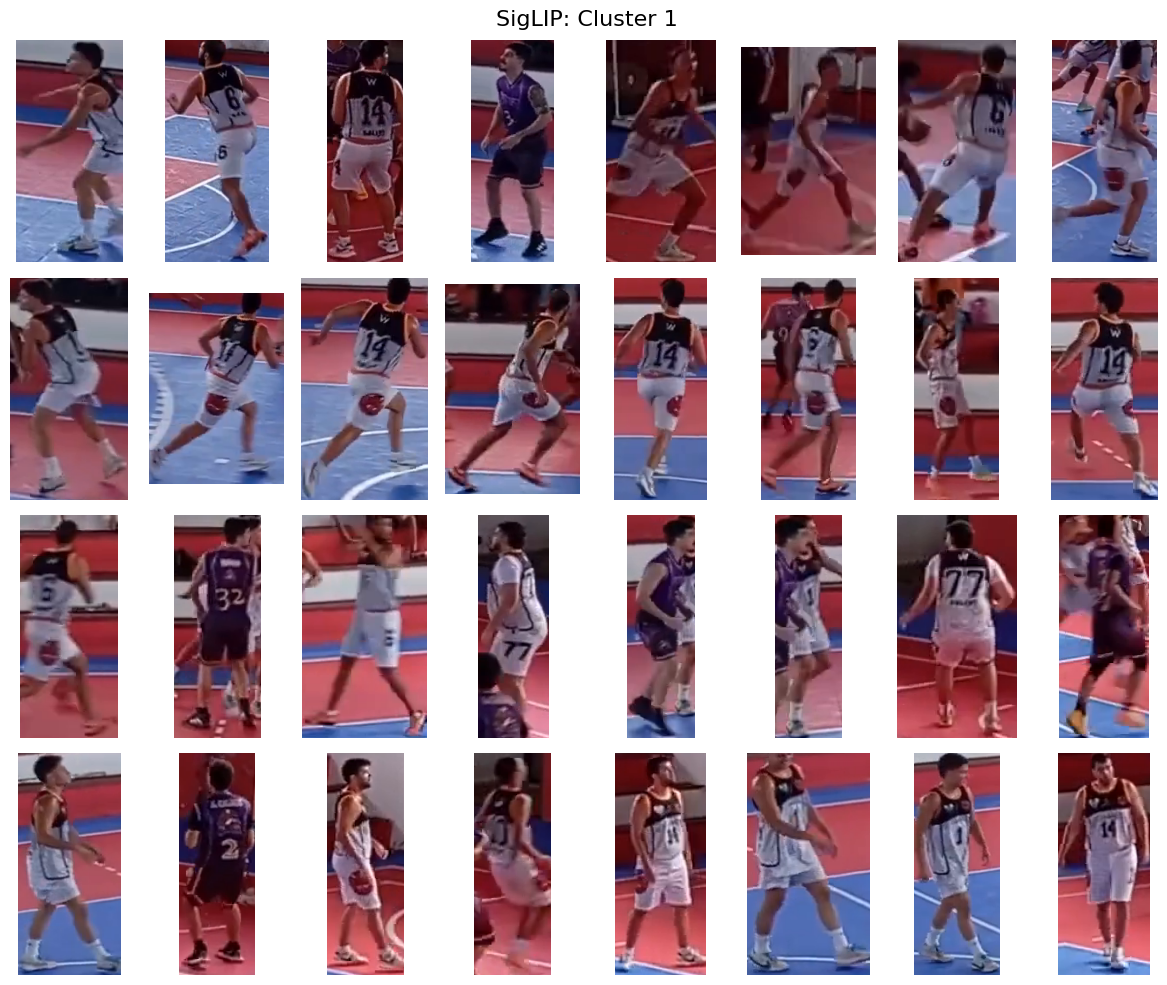

In [15]:
# %% [Cell 5]
siglip_cluster_0 = [golden_crops[i] for i in range(len(golden_crops)) if labels_siglip[i] == 0]
siglip_cluster_1 = [golden_crops[i] for i in range(len(golden_crops)) if labels_siglip[i] == 1]

plot_crop_grid(siglip_cluster_0, "SigLIP: Cluster 0", num_items=32)
plot_crop_grid(siglip_cluster_1, "SigLIP: Cluster 1", num_items=32)

# HSV Debugging

[*] Extraindo Histogramas HSV...
[*] Reduzindo dimensao com UMAP e clusterizando...


/home/victor/miniconda3/envs/tail/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


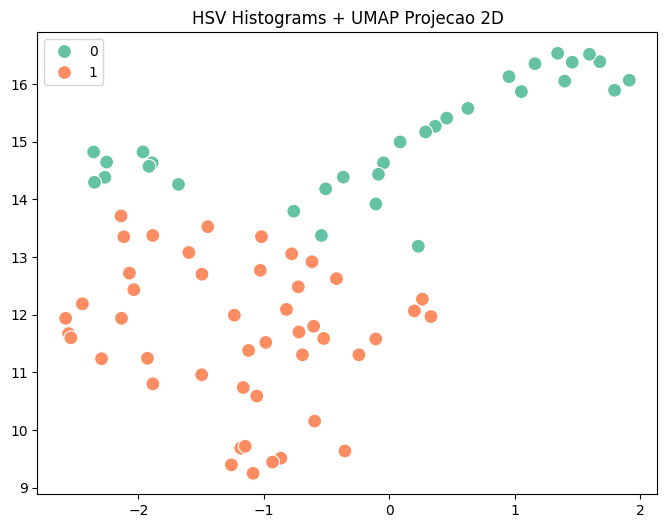

In [16]:
# %% [Cell 6]
print("[*] Extraindo Histogramas HSV...")
hsv_features = []

for crop in golden_crops:
    mask = np.any(crop > 0, axis=-1).astype(np.uint8) * 255
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    
    # Canal 0 (Matiz/Cor) e Canal 1 (Saturacao). Ignora brilho.
    hist = cv2.calcHist([hsv], [0, 1], mask, [32, 16], [0, 180, 0, 256])
    cv2.normalize(hist, hist, alpha=1.0, norm_type=cv2.NORM_L2)
    hsv_features.append(hist.flatten())

hsv_features = np.array(hsv_features)

print("[*] Reduzindo dimensao com UMAP e clusterizando...")
reducer_hsv = umap.UMAP(n_components=2, metric='cosine', random_state=42)
proj_hsv = reducer_hsv.fit_transform(hsv_features)

kmeans_hsv = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_hsv = kmeans_hsv.fit_predict(proj_hsv)

# Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=proj_hsv[:, 0], y=proj_hsv[:, 1], hue=labels_hsv, palette="Set2", s=100)
plt.title("HSV Histograms + UMAP Projecao 2D")
plt.show()

# HSV Accountability Check

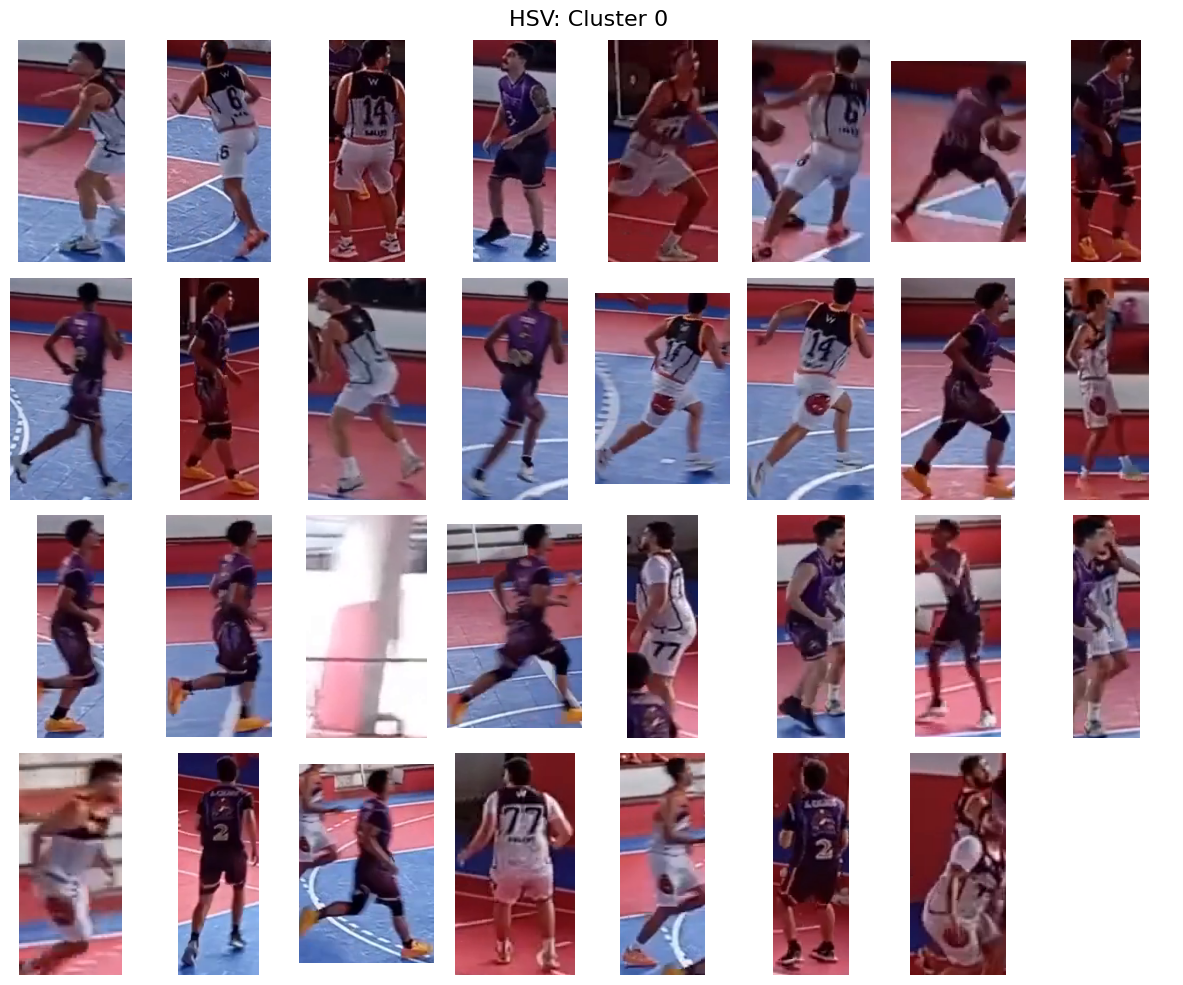

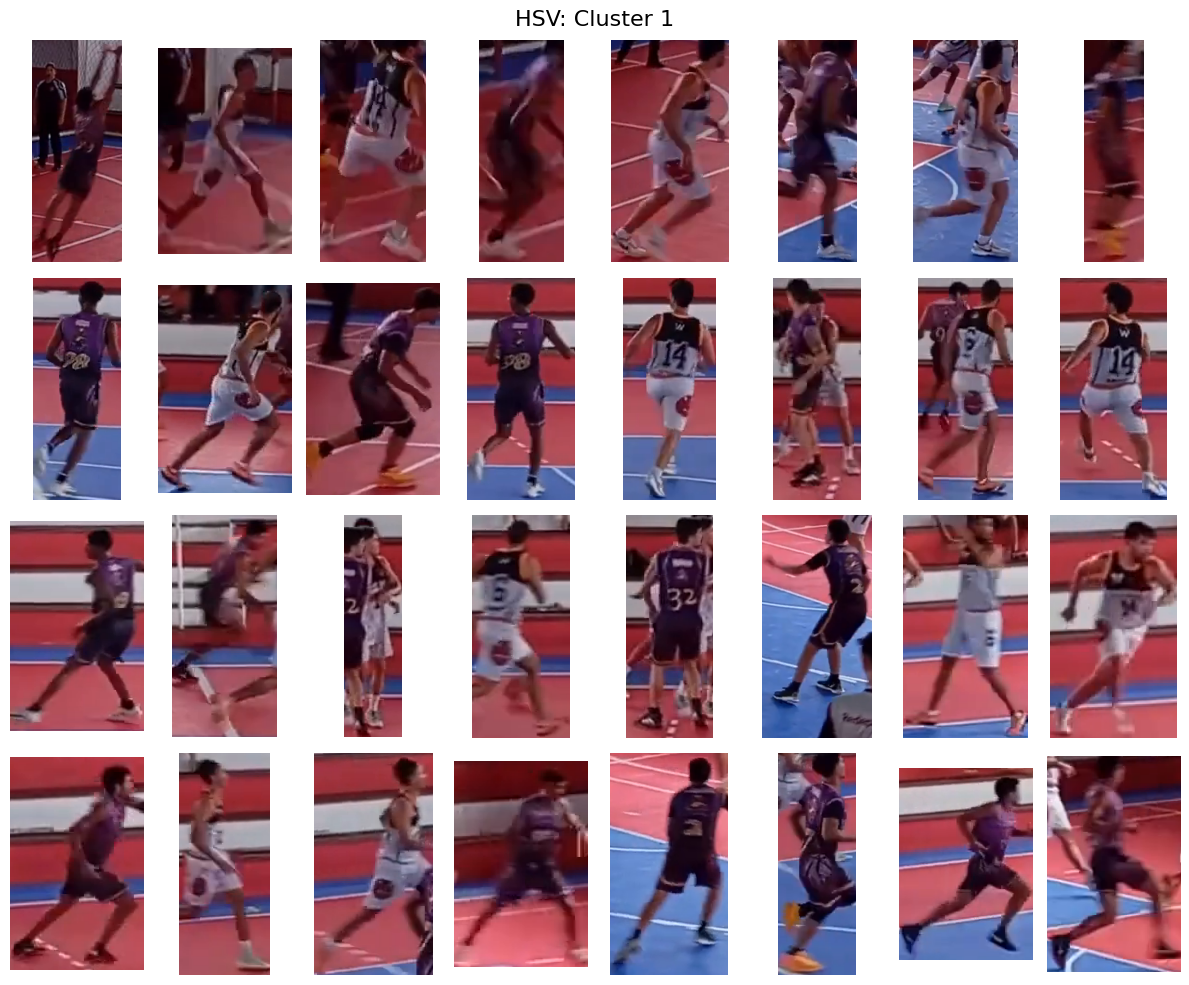

In [17]:
# %% [Cell 7]
hsv_cluster_0 = [golden_crops[i] for i in range(len(golden_crops)) if labels_hsv[i] == 0]
hsv_cluster_1 = [golden_crops[i] for i in range(len(golden_crops)) if labels_hsv[i] == 1]

plot_crop_grid(hsv_cluster_0, "HSV: Cluster 0", num_items=32)
plot_crop_grid(hsv_cluster_1, "HSV: Cluster 1", num_items=32)